# Transformer Hyperparameter Grid Search

## Setup & imports

In [1]:
import os
import sys
import json
import hashlib
import time
import gc
from itertools import product
from pathlib import Path
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import tensorflow as tf

current_dir = Path.cwd()
project_root = os.environ.get('PROJECT_ROOT') or os.environ.get('MASTERPROEF_ROOT')
if not project_root:
    if current_dir.name == 'notebooks':
        project_root = str(current_dir.parent)
    elif (current_dir / 'notebooks').exists():
        project_root = str(current_dir)
    else:
        candidate = current_dir
        while candidate != candidate.parent:
            if (candidate / 'config.py').exists():
                project_root = str(candidate)
                break
            candidate = candidate.parent
        else:
            project_root = '/Users/d1ff1cult/Local/masterproef_new'

project_root = os.path.abspath(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from config import ExperimentConfig, DataConfig, ModelConfig, TrainingConfig
from data import DataPipeline
from models import ProbabilisticTransformer
from core.trainer import Trainer
from core.evaluator import Evaluator
from transformations import StandardScalingTransformation

# GPU memory growth
try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    if gpus:
        print(f"Enabled memory growth for {len(gpus)} GPU(s)")
except Exception as exc:
    print(f"GPU config skipped: {exc}")

print(f"Project root: {project_root}")

2026-02-15 13:22:25.729308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771158145.793412 1176662 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771158145.822280 1176662 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771158145.975365 1176662 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771158145.975383 1176662 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771158145.975385 1176662 computation_placer.cc:177] computation placer alr

Enabled memory growth for 1 GPU(s)
Project root: /home/d1ff1cult/masterproef_new


## Configuration

In [2]:
RESULTS_DIR = Path(project_root) / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = RESULTS_DIR / "transformer_grid_search_results.json"

DATASET_NAME = "BE_ENTSOE"
TEST_MONTHS = 6
INPUT_WINDOW = 168
OUTPUT_HORIZON = 24
EPOCHS = 25
BATCH_SIZE = 32
PATIENCE = 5
VALIDATION_SPLIT = 0.1

# Parameter grid for grid search
PARAM_GRID = {
    "d_model": [128, 224],
    "num_heads": [4, 7],
    "num_layers": [2, 3],
    "ff_dim": [256, 448],
    "dropout": [0.1, 0.15],
    "learning_rate": [5e-4, 7e-4],
}

def param_dict_to_hash(params: Dict[str, Any], data_fingerprint: str = "") -> str:
    # make a deterministic hash for a parameter dict
    canonical = json.dumps({"params": params, "data": data_fingerprint}, sort_keys=True)
    return hashlib.sha256(canonical.encode()).hexdigest()[:16]

# Generate all combinations
param_names = list(PARAM_GRID.keys())
param_values = list(PARAM_GRID.values())
param_combinations = [dict(zip(param_names, v)) for v in product(*param_values)]

# Data fingerprint to invalidate cache when data config changes
DATA_FINGERPRINT = f"{DATASET_NAME}_{TEST_MONTHS}_{INPUT_WINDOW}_{OUTPUT_HORIZON}"

print(f"Total configurations to evaluate: {len(param_combinations)}")
print(f"Cache file: {CACHE_FILE}")

Total configurations to evaluate: 64
Cache file: /home/d1ff1cult/masterproef_new/results/transformer_grid_search_results.json


## Load cache and data

In [3]:
def load_cache() -> Dict[str, Any]:
    # Load existing grid search results from disk
    if CACHE_FILE.exists():
        with open(CACHE_FILE, "r") as f:
            return json.load(f)
    return {}

def save_cache(cache: Dict[str, Any]) -> None:
    # Save grid search results to disk
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)

# Load existing results
cache = load_cache()
n_cached = len(cache)
print(f"Loaded {n_cached} cached results from previous runs")

# Load data
data_config = DataConfig(
    dataset_name=DATASET_NAME,
    test_duration_months=TEST_MONTHS,
    input_window=INPUT_WINDOW,
    output_horizon=OUTPUT_HORIZON,
)
pipeline = DataPipeline(data_config)
train_df, val_df, test_df = pipeline.get_data_splits()
X_train_raw, y_train_raw = pipeline.create_sequences(train_df)
X_val_raw, y_val_raw = pipeline.create_sequences(val_df)
X_test_raw, y_test_raw = pipeline.create_sequences(test_df)

# Transform data
transform = StandardScalingTransformation()
transform.fit(X_train_raw, y_train_raw)
X_train, y_train = transform.transform(X_train_raw, y_train_raw)
X_val, y_val = transform.transform(X_val_raw, y_val_raw)
X_test, y_test = transform.transform(X_test_raw, y_test_raw)

print(f"Data shapes - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation: {X_val.shape}, Test: {X_test.shape}")

Loaded 117 cached results from previous runs
Data shapes - X_train: (10367, 168, 28), y_train: (10367, 24)
Validation: (1997, 168, 28), Test: (1128, 168, 28)


## Grid search loop

In [4]:
def run_single_config(params: Dict[str, Any], cache: Dict[str, Any], data_fingerprint: str = "") -> Dict[str, Any]:
    # Train and evaluate one configuration: returns cached result if available otherwise trains and caches

    param_hash = param_dict_to_hash(params, data_fingerprint)
    if param_hash in cache:
        return cache[param_hash]

    tf.keras.backend.clear_session()
    gc.collect()

    model_config = ModelConfig(
        d_model=params["d_model"],
        num_heads=params["num_heads"],
        num_layers=params["num_layers"],
        ff_dim=params["ff_dim"],
        dropout=params["dropout"],
    )
    training_config = TrainingConfig(
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        learning_rate=params["learning_rate"],
        patience=PATIENCE,
        validation_split=VALIDATION_SPLIT,
    )
    exp_config = ExperimentConfig(
        name=f"grid_{param_hash}",
        data_config=data_config,
        model_config=model_config,
        training_config=training_config,
        head_type="johnson_su",
        transform_type="standard_scaling",
    )

    model = ProbabilisticTransformer(exp_config)
    trainer = Trainer(exp_config)

    start = time.time()
    history = trainer.train(model, X_train, y_train, X_val, y_val)
    fit_time = time.time() - start

    evaluator = Evaluator(model, transform)
    metrics = evaluator.evaluate(X_test, y_test_raw)

    # Store epoch metrics
    history_dict = None
    if history and history.history:
        history_dict = {k: [float(x) for x in v] for k, v in history.history.items()}

    result = {
        "params": params,
        "param_hash": param_hash,
        "metrics": {k: float(v) for k, v in metrics.items()},
        "fit_time_s": fit_time,
        "history": history_dict,
    }

    cache[param_hash] = result
    save_cache(cache)

    del model
    del trainer
    del evaluator
    tf.keras.backend.clear_session()
    gc.collect()

    return result

In [5]:
# Run grid search
all_results = []

for i, params in enumerate(param_combinations):
    param_hash = param_dict_to_hash(params, DATA_FINGERPRINT)
    is_cached = param_hash in cache
    status = "(cached)" if is_cached else "(training)"
    print(f"\n[{i+1}/{len(param_combinations)}] {params} {status}")

    try:
        result = run_single_config(params, cache, DATA_FINGERPRINT)
        all_results.append(result)
        m = result["metrics"]
        print(f"    MAE={m['MAE']:.4f}, RMSE={m['RMSE']:.4f}, fit_time={result['fit_time_s']:.1f}s")
    except Exception as e:
        print(f"    FAILED: {e}")
        import traceback
        traceback.print_exc()


[1/64] {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 256, 'dropout': 0.1, 'learning_rate': 0.0005} (cached)
    MAE=21.2663, RMSE=28.4279, fit_time=55.3s

[2/64] {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 256, 'dropout': 0.1, 'learning_rate': 0.0007} (cached)
    MAE=19.5623, RMSE=26.4536, fit_time=55.2s

[3/64] {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 256, 'dropout': 0.15, 'learning_rate': 0.0005} (cached)
    MAE=19.6446, RMSE=26.5228, fit_time=61.1s

[4/64] {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 256, 'dropout': 0.15, 'learning_rate': 0.0007} (cached)
    MAE=19.8474, RMSE=26.6455, fit_time=56.9s

[5/64] {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 448, 'dropout': 0.1, 'learning_rate': 0.0005} (cached)
    MAE=22.2911, RMSE=30.0343, fit_time=53.9s

[6/64] {'d_model': 128, 'num_heads': 4, 'num_layers': 2, 'ff_dim': 448, 'dropout': 0.1, 'learning_rate': 0.0007} (cached)
    MAE=19.6918, RMSE=26.5597,

## Results summary

In [6]:
# Build results dataframe
rows = []
for r in all_results:
    row = {**r["params"], **r["metrics"], "fit_time_s": r["fit_time_s"]}
    rows.append(row)

results_df = pd.DataFrame(rows)

# Sort by MAE
results_df = results_df.sort_values("MAE").reset_index(drop=True)

print("Results (sorted by MAE):")
display(results_df)

best = results_df.iloc[0]
print(f"\nBest configuration (lowest MAE):")
for k in PARAM_GRID.keys():
    print(f"  {k}: {best[k]}")
print(f"  MAE: {best['MAE']:.4f}, RMSE: {best['RMSE']:.4f}")

Results (sorted by MAE):


,d_model,num_heads,num_layers,ff_dim,dropout,learning_rate,MAE,MSE,RMSE,fit_time_s
0,224,7,3,256,0.15,0.0007,18.783015,649.962387,25.494360,118.699539
1,128,7,3,448,0.10,0.0007,18.922643,671.696145,25.917101,88.257742
2,224,4,2,448,0.15,0.0007,19.025278,665.013953,25.787864,69.839018
3,224,4,2,448,0.15,0.0005,19.206827,682.149257,26.117987,69.532976
4,224,4,2,256,0.15,0.0005,19.418416,674.774417,25.976420,80.867015
...,...,...,...,...,...,...,...,...,...,...
59,128,4,2,448,0.10,0.0005,22.291076,902.058155,30.034283,53.947489
60,128,7,3,256,0.15,0.0005,22.321212,870.959178,29.512018,83.010317
61,224,7,3,256,0.10,0.0005,23.008652,1030.618655,32.103250,128.178023
62,224,4,3,448,0.15,0.0005,23.253304,986.148587,31.403003,116.057703



Best configuration (lowest MAE):
  d_model: 224.0
  num_heads: 7.0
  num_layers: 3.0
  ff_dim: 256.0
  dropout: 0.15
  learning_rate: 0.0007
  MAE: 18.7830, RMSE: 25.4944


## Visualization

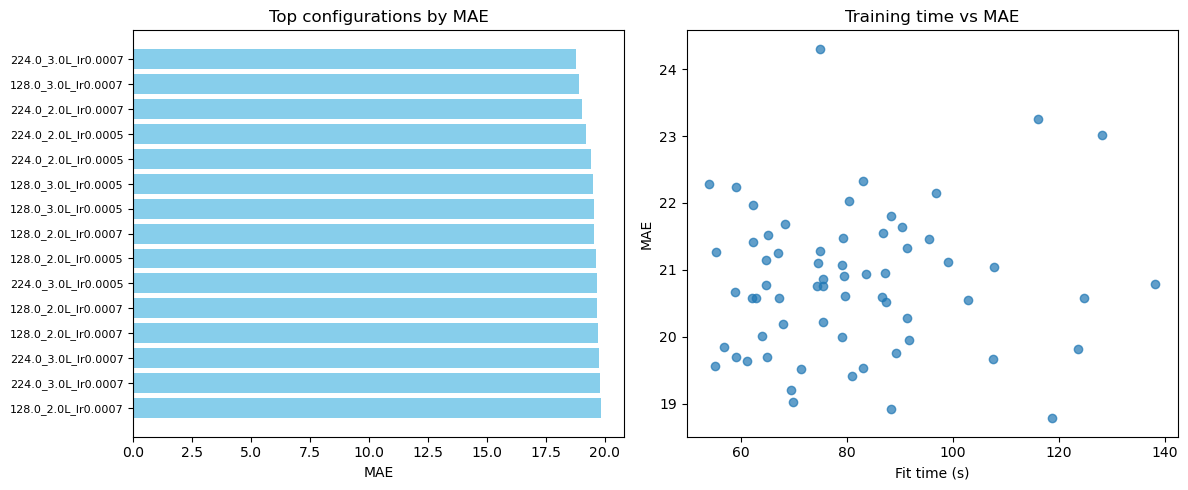

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart MAE by config
top_n = min(15, len(results_df))
ax1 = axes[0]
config_labels = [f"{row['d_model']}_{row['num_layers']}L_lr{row['learning_rate']}" for _, row in results_df.head(top_n).iterrows()]
ax1.barh(range(top_n), results_df["MAE"].head(top_n).values, color="skyblue")
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(config_labels, fontsize=8)
ax1.set_xlabel("MAE")
ax1.set_title("Top configurations by MAE")
ax1.invert_yaxis()

# Scatter fit_time vs MAE
ax2 = axes[1]
ax2.scatter(results_df["fit_time_s"], results_df["MAE"], alpha=0.7)
ax2.set_xlabel("Fit time (s)")
ax2.set_ylabel("MAE")
ax2.set_title("Training time vs MAE")

plt.tight_layout()
plt.show()

## Refined grid search

Based on the previous results, the best parameters were often at the upper boundaries of the search grid

In [9]:
# Refined parameter grid
REFINED_PARAM_GRID = {
    "d_model": [224, 256],
    "num_heads": [7, 8],
    "num_layers": [3, 4],
    "ff_dim": [256, 512],
    "dropout": [0.15, 0.2],
    "learning_rate": [7e-4, 9e-4],
}

from itertools import product

# Generate combinations
refined_param_names = list(REFINED_PARAM_GRID.keys())
refined_param_values = list(REFINED_PARAM_GRID.values())
refined_combinations = [dict(zip(refined_param_names, v)) for v in product(*refined_param_values)]

print(f"Refined configurations to evaluate: {len(refined_combinations)}")

for i, params in enumerate(refined_combinations):
    
    param_hash = param_dict_to_hash(params, DATA_FINGERPRINT)
    is_cached = param_hash in cache
    status = "(cached)" if is_cached else "(training)"
    print(f"\n[Refined {i+1}/{len(refined_combinations)}] {params} {status}")

    try:
        result = run_single_config(params, cache, DATA_FINGERPRINT)
        all_results.append(result)
        m = result["metrics"]
        print(f"    MAE={m['MAE']:.4f}, RMSE={m['RMSE']:.4f}, fit_time={result['fit_time_s']:.1f}s")
    except Exception as e:
        print(f"failed: {e}")

# Update results dataframe
rows = []
for r in all_results:
    row = {**r["params"], **r["metrics"], "fit_time_s": r["fit_time_s"]}
    rows.append(row)

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("MAE").reset_index(drop=True)

print("\nUpdated Results (Top 10 sorted by MAE):")
display(results_df.head(10))

best = results_df.iloc[0]
print(f"\nBest configuration overall:")
for k in REFINED_PARAM_GRID.keys():
    if k in best:
        print(f"  {k}: {best[k]}")
print(f"  MAE: {best['MAE']:.4f}, RMSE: {best['RMSE']:.4f}")

Refined configurations to evaluate: 64

[Refined 1/64] {'d_model': 224, 'num_heads': 7, 'num_layers': 3, 'ff_dim': 256, 'dropout': 0.15, 'learning_rate': 0.0007} (cached)
    MAE=18.7830, RMSE=25.4944, fit_time=118.7s

[Refined 2/64] {'d_model': 224, 'num_heads': 7, 'num_layers': 3, 'ff_dim': 256, 'dropout': 0.15, 'learning_rate': 0.0009} (cached)
    MAE=20.3228, RMSE=27.1542, fit_time=107.6s

[Refined 3/64] {'d_model': 224, 'num_heads': 7, 'num_layers': 3, 'ff_dim': 256, 'dropout': 0.2, 'learning_rate': 0.0007} (cached)
    MAE=20.5719, RMSE=27.5212, fit_time=125.6s

[Refined 4/64] {'d_model': 224, 'num_heads': 7, 'num_layers': 3, 'ff_dim': 256, 'dropout': 0.2, 'learning_rate': 0.0009} (cached)
    MAE=20.9726, RMSE=28.8679, fit_time=115.9s

[Refined 5/64] {'d_model': 224, 'num_heads': 7, 'num_layers': 3, 'ff_dim': 512, 'dropout': 0.15, 'learning_rate': 0.0007} (cached)
    MAE=19.5830, RMSE=26.0194, fit_time=114.8s

[Refined 6/64] {'d_model': 224, 'num_heads': 7, 'num_layers': 3, 'f

I0000 00:00:1771158156.573478 1176662 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7483 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1


Epoch 1/25


I0000 00:00:1771158162.991152 1177010 service.cc:152] XLA service 0x76dbb4004670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771158162.991169 1177010 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-02-15 13:22:43.189757: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771158164.213274 1177010 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/324 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 1.6092

I0000 00:00:1771158172.140423 1177010 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


324/324 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - loss: 1.0799 - val_loss: 1.1170 - learning_rate: 7.0000e-04
Epoch 2/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.7543 - val_loss: 1.0379 - learning_rate: 7.0000e-04
Epoch 3/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.6133 - val_loss: 1.0109 - learning_rate: 7.0000e-04
Epoch 4/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 0.5161 - val_loss: 1.3724 - learning_rate: 7.0000e-04
Epoch 5/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 0.4359 - val_loss: 1.1698 - learning_rate: 7.0000e-04
Epoch 6/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.3736 - val_loss: 1.0512 - learning_rate: 7.0000e-04
Epoch 7/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.3319 - val_loss: 1.0212 - learning_rate: 7.0000e-04
Epoch 8/25
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.2901 - val_loss: 1.3159 - learning_rate: 7.0000e-04
    MAE=21.7555, RMSE=29.7204, fit_time=121.7s

[Refined 56/64] {'d_model': 256, 'n

,d_model,num_heads,num_layers,ff_dim,dropout,learning_rate,MAE,MSE,RMSE,fit_time_s
0,224,7,3,256,0.15,0.0007,18.783015,649.962387,25.494360,118.699539
1,224,7,3,256,0.15,0.0007,18.783015,649.962387,25.494360,118.699539
2,128,7,3,448,0.10,0.0007,18.922643,671.696145,25.917101,88.257742
3,224,4,2,448,0.15,0.0007,19.025278,665.013953,25.787864,69.839018
4,224,4,2,448,0.15,0.0005,19.206827,682.149257,26.117987,69.532976
5,224,8,4,256,0.20,0.0009,19.350001,695.367394,26.369820,175.933279
6,224,4,2,256,0.15,0.0005,19.418416,674.774417,25.976420,80.867015
7,128,4,3,448,0.10,0.0005,19.514155,701.711706,26.489842,71.347602
8,128,7,3,256,0.10,0.0005,19.528210,685.045168,26.173368,83.020000
9,128,4,2,256,0.10,0.0007,19.562296,699.791221,26.453567,55.171479



Best configuration overall:
  d_model: 224.0
  num_heads: 7.0
  num_layers: 3.0
  ff_dim: 256.0
  dropout: 0.15
  learning_rate: 0.0007
  MAE: 18.7830, RMSE: 25.4944
